In [6]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
#!pip install botorch
#!pip install ax-platform
#!pip install botorch gpytorch
#!pip install seaborn
#!git clone https://github.com/uber-research/TuRBO.git
#cd TuRBO
#!pip install -e .   # installs the library in editable mode
#import turbo  # if that’s the module name inside the repo
#print("TuRBO installed successfully")

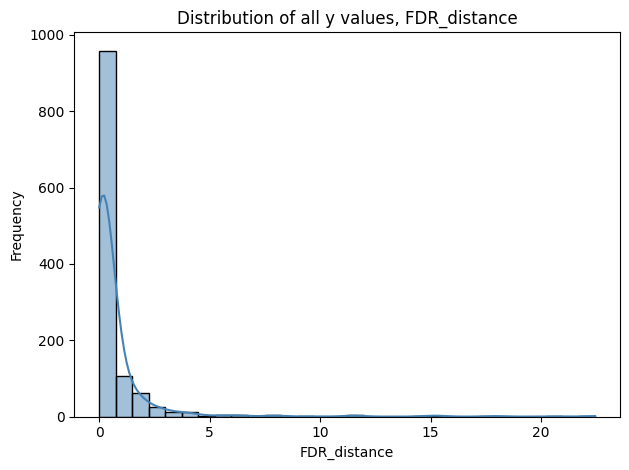

Original Y range: [0.0000, 22.4500]
TuRBO Batch Optimization with Warm Start

1. Loading 1200 total points...
   X normalized to [0.0000, 1.0000]
   Y transformed: mean=0.0000, std=1.0000
   Best Y value: 11.2865

2. Generating 40 batches of 10 candidates...
Generated batch 1/40 (TR length: 0.8000)
Generated batch 2/40 (TR length: 0.8000)
Generated batch 3/40 (TR length: 0.8000)
Generated batch 4/40 (TR length: 0.8000)
Generated batch 5/40 (TR length: 0.8000)
Generated batch 6/40 (TR length: 0.8000)
Generated batch 7/40 (TR length: 0.8000)
Generated batch 8/40 (TR length: 0.8000)
Generated batch 9/40 (TR length: 0.8000)
Generated batch 10/40 (TR length: 0.8000)
Generated batch 11/40 (TR length: 0.8000)
Generated batch 12/40 (TR length: 0.8000)
Generated batch 13/40 (TR length: 0.8000)
Generated batch 14/40 (TR length: 0.8000)
Generated batch 15/40 (TR length: 0.8000)
Generated batch 16/40 (TR length: 0.8000)
Generated batch 17/40 (TR length: 0.8000)
Generated batch 18/40 (TR length: 0.

In [7]:
import itertools
import math
import time
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns

import torch
import numpy as np
from torch.quasirandom import SobolEngine
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.utils.transforms import normalize, unnormalize, standardize
import warnings
warnings.filterwarnings('ignore')

def set_random_seed(seed=42):
    """
    Set random seeds for reproducibility across NumPy, PyTorch, and Python's random.
    
    Args:
        seed: Random seed value
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # For deterministic behavior (may impact performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class TuRBOBatch:
    """
    Trust Region Bayesian Optimization with batch candidate generation.
    Based on the TuRBO algorithm (Eriksson et al., 2019).
    """
    
    def __init__(
        self,
        dim,
        batch_size=10,
        n_trust_regions=1,
        length_min=0.5**7,
        length_max=1.6,
        length_init=0.8,
        success_tolerance=3,
        failure_tolerance=5,
        use_log_transform=False,
        dtype=torch.double,
        device='cpu',
        seed=None
    ):
        """
        Initialize TuRBO optimizer.
        
        Args:
            dim: Problem dimensionality
            batch_size: Number of points to generate per batch
            n_trust_regions: Number of independent trust regions
            length_min: Minimum trust region length
            length_max: Maximum trust region length
            length_init: Initial trust region length
            success_tolerance: Successes before expanding trust region
            failure_tolerance: Failures before shrinking trust region
            use_log_transform: Whether to log-transform Y values
            dtype: PyTorch data type
            device: PyTorch device
        """
        self.dim = dim
        self.batch_size = batch_size
        self.n_trust_regions = n_trust_regions
        self.length_min = length_min
        self.length_max = length_max
        self.length_init = length_init
        self.success_tolerance = success_tolerance
        self.failure_tolerance = failure_tolerance
        self.use_log_transform = use_log_transform
        self.dtype = dtype
        self.device = device
        self.seed = seed

        # Set random seed if provided
        if seed is not None:
            set_random_seed(seed)

        # Initialize trust region states
        self.reset_trust_regions()
        
        # Bounds (will be set from data)
        self.bounds = None
        
    def reset_trust_regions(self):
        """Reset trust region parameters."""
        self.length = [self.length_init] * self.n_trust_regions
        self.success_counter = [0] * self.n_trust_regions
        self.failure_counter = [0] * self.n_trust_regions
        self.best_value = [float('-inf')] * self.n_trust_regions
        self.center = [None] * self.n_trust_regions
        
    def load_warmstart(self, X_init, Y_init):
        """
        Load warm-start points with normalization and optional Y transformation.
        
        Args:
            X_init: (n_init, dim) array of initial input points
            Y_init: (n_init, 1) or (n_init,) array of initial observations
            
        Returns:
            X_normalized: Normalized X in [0, 1]^d
            Y_transformed: Standardized (and optionally log-transformed) Y
        """
        # Convert to torch tensors
        X = torch.tensor(X_init, dtype=self.dtype, device=self.device)
        Y = torch.tensor(Y_init, dtype=self.dtype, device=self.device)
        
        if Y.ndim == 1:
            Y = Y.unsqueeze(-1)
            
        # Store original bounds
        self.bounds = torch.stack([X.min(dim=0)[0], X.max(dim=0)[0]])
        
        # Normalize X to [0, 1]^d
        X_normalized = normalize(X, self.bounds)
        
        # Optional log transform for Y
        if self.use_log_transform:
            # Ensure all Y values are positive
            if (Y <= 0).any():
                print("Warning: Non-positive Y values detected. Adding offset for log transform.")
                Y = Y - Y.min() + 1e-6
            Y_log = torch.log(Y)
            Y_transformed = standardize(Y_log)
        else:
            Y_transformed = standardize(Y)
            
        # Initialize trust region centers
        best_idx = Y_transformed.argmax()
        for tr in range(self.n_trust_regions):
            self.center[tr] = X_normalized[best_idx].clone()
            self.best_value[tr] = Y_transformed[best_idx].item()
            
        return X_normalized, Y_transformed
    
    def _create_tr_bounds(self, tr_idx):
        """Create bounds for trust region."""
        center = self.center[tr_idx]
        length = self.length[tr_idx]
        
        lb = torch.clamp(center - length / 2.0, 0.0, 1.0)
        ub = torch.clamp(center + length / 2.0, 0.0, 1.0)
        
        return torch.stack([lb, ub])
    
    def _update_trust_region(self, tr_idx, new_y, new_x):
        """Update trust region based on new observation."""
        # Check if we improved
        if new_y > self.best_value[tr_idx]:
            self.success_counter[tr_idx] += 1
            self.failure_counter[tr_idx] = 0
            self.best_value[tr_idx] = new_y
            self.center[tr_idx] = new_x.clone()
        else:
            self.success_counter[tr_idx] = 0
            self.failure_counter[tr_idx] += 1
            
        # Expand trust region
        if self.success_counter[tr_idx] >= self.success_tolerance:
            self.length[tr_idx] = min(2.0 * self.length[tr_idx], self.length_max)
            self.success_counter[tr_idx] = 0
            
        # Shrink trust region
        if self.failure_counter[tr_idx] >= self.failure_tolerance:
            self.length[tr_idx] = max(0.5 * self.length[tr_idx], self.length_min)
            self.failure_counter[tr_idx] = 0
            
    def generate_batch(self, X_train, Y_train, tr_idx=0):
        """
        Generate a batch of candidate points using BO within trust region.
        
        Args:
            X_train: (n, dim) normalized training inputs
            Y_train: (n, 1) transformed training outputs
            tr_idx: Trust region index
            
        Returns:
            X_next: (batch_size, dim) normalized candidate points
        """
        # Fit GP model
        model = SingleTaskGP(X_train, Y_train)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
        
        # Create trust region bounds
        tr_bounds = self._create_tr_bounds(tr_idx)
        
        # Create acquisition function
        qEI = qExpectedImprovement(model, best_f=Y_train.max())
        
        # Optimize acquisition function
        candidates, _ = optimize_acqf(
            acq_function=qEI,
            bounds=tr_bounds,
            q=self.batch_size,
            num_restarts=10,
            raw_samples=512,
            options={"batch_limit": 5, "maxiter": 200},
        )
        
        return candidates
    
    def generate_all_batches(self, X_train, Y_train, n_batches=1):
        """
        Generate multiple batches of candidates.
        
        Args:
            X_train: (n, dim) normalized training inputs
            Y_train: (n, 1) transformed training outputs
            n_batches: Number of batches to generate
            
        Returns:
            all_candidates: (n_batches * batch_size, dim) normalized candidates
        """
        all_candidates = []
        
        for batch_idx in range(n_batches):
            # Select trust region (can implement more sophisticated selection)
            tr_idx = batch_idx % self.n_trust_regions
            
            # Generate batch
            candidates = self.generate_batch(X_train, Y_train, tr_idx)
            all_candidates.append(candidates)
            
            print(f"Generated batch {batch_idx + 1}/{n_batches} "
                  f"(TR length: {self.length[tr_idx]:.4f})")
        
        return torch.cat(all_candidates, dim=0)
    
    def denormalize_candidates(self, X_normalized):
        """
        Convert normalized candidates back to original space.
        
        Args:
            X_normalized: (n, dim) candidates in [0, 1]^d
            
        Returns:
            X_original: (n, dim) candidates in original space
        """
        if self.bounds is None:
            raise ValueError("Must call load_warmstart first to set bounds")
            
        return unnormalize(X_normalized, self.bounds)
    
    def inverse_transform_y(self, Y_transformed):
        """
        Inverse transform Y values (if log transform was used).
        Note: This is approximate due to standardization.
        """
        if self.use_log_transform:
            return torch.exp(Y_transformed)
        return Y_transformed


# Example usage
if __name__ == "__main__":
    # Simulate 400 warm-start points
    dim = 28
    n_total = 1200
    RANDOM_SEED = 42  # Change this value for different random runs
    set_random_seed(RANDOM_SEED)
    # Generate synthetic data (replace with your actual data)
    #X_init = np.random.uniform(0, 10, (n_warmstart, dim))
    #Y_init = -np.sum((X_init - 5)**2, axis=1) + np.random.randn(n_warmstart) * 0.1
    # Convert to NumPy arrays if they're pandas objects
    X_init_df = pd.read_csv('../PNN_round2_TuRBO/round1_x_values.csv')
    X_init = X_init_df.values  # Convert to NumPy array
    Y_init_df = pd.read_csv('../PNN_round2_TuRBO/round1_y_values.csv')
    Y_init = Y_init_df['FDR_distance'].values  # Or use .iloc[:, 0] for first column
    
    X_round2_df = pd.read_csv('../PNN_round3_TuRBO/round2_x_values.csv')
    X_round2 = X_round2_df.values  # Convert to NumPy array
    Y_round2_df = pd.read_csv('../PNN_round3_TuRBO/round2_y_values.csv')
    Y_round2 = Y_round2_df['FDR_distance'].values  # Or use .iloc[:, 0] for first column
    
    X_round3_df = pd.read_csv('round3_x_values.csv')
    X_round3 = X_init_df.values  # Convert to NumPy array
    Y_round3_df = pd.read_csv('round3_y_values.csv')
    Y_round3 = Y_init_df['FDR_distance'].values  # Or use .iloc[:, 0] for first column

    X_all = np.vstack([X_init, X_round2, X_round3])
    Y_all = np.concatenate([Y_init, Y_round2, Y_round3])

    # Plot the distribution of y
    sns.histplot(Y_all, kde=True, bins=30, color='steelblue')
    
    plt.title(f"Distribution of all y values, FDR_distance")
    plt.xlabel("FDR_distance")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    print(f"Original Y range: [{Y_all.min():.4f}, {Y_all.max():.4f}]")
    #print(f"Log-scaled Y range: [{y_scaled.min():.4f}, {y_scaled.max():.4f}]")
    
    print("=" * 70)
    print("TuRBO Batch Optimization with Warm Start")
    print("=" * 70)
    
    # Initialize TuRBO
    turbo = TuRBOBatch(
        dim=dim,
        batch_size=10,  # Generate 10 points per batch
        n_trust_regions=1,
        use_log_transform=False,  # Set True if Y values are positive and span orders of magnitude
        dtype=torch.double,
        device='cpu',
        seed=RANDOM_SEED  # Pass seed for reproducibility
)
    
    # Step 1: Load warm-start data with normalization
    print(f"\n1. Loading {n_total} total points...")
    X_train, Y_train = turbo.load_warmstart(X_all, Y_all)
    print(f"   X normalized to [{X_train.min():.4f}, {X_train.max():.4f}]")
    print(f"   Y transformed: mean={Y_train.mean():.4f}, std={Y_train.std():.4f}")
    print(f"   Best Y value: {Y_train.max():.4f}")
    
    # Step 2: Generate 400 new candidate points in batches of 10
    n_batches = 40  # 40 batches × 10 points = 400 candidates
    print(f"\n2. Generating {n_batches} batches of {turbo.batch_size} candidates...")
    X_candidates_normalized = turbo.generate_all_batches(X_train, Y_train, n_batches)
    
    # Step 3: Denormalize candidates back to original space
    print(f"\n3. Denormalizing {len(X_candidates_normalized)} candidates...")
    X_candidates = turbo.denormalize_candidates(X_candidates_normalized)
    
    print(f"\nCandidates shape: {X_candidates.shape}")
    print(f"Candidates range: [{X_candidates.min():.4f}, {X_candidates.max():.4f}]")
    print("\nFirst 5 candidates:")
    print(X_candidates[:5].numpy())
    
    # Optional: Update trust region with new observations
    print("\n4. Example trust region update (after evaluating candidates)...")
    for i in range(min(3, len(X_candidates))):
        # Simulate evaluation (replace with actual objective function)
        y_new = torch.randn(1, 1) * 0.1 + Y_train.max()
        turbo._update_trust_region(0, y_new.item(), X_candidates_normalized[i])
        print(f"   After evaluation {i+1}: TR length = {turbo.length[0]:.4f}")
    
    # Step 5: Save candidates to CSV
    print("\n5. Saving candidates to CSV...")
    import pandas as pd
    
    # Convert to numpy and create DataFrame
    X_candidates_np = X_candidates.cpu().numpy()
    column_names = [f'x{i+1}' for i in range(dim)]
    df_candidates = pd.DataFrame(X_candidates_np, columns=column_names)
    
    # Save to CSV
    df_candidates.to_csv('X_candidates_next400.csv', index=False, float_format="%.3f")
    print("Next 400 candidate points saved to X_candidates_next400.csv")
    
    print("\n" + "=" * 70)
    print("Optimization complete!")
    print("=" * 70)